In [2]:
# ============================================================
# PROJET : Prévision des rendements et de la volatilité
#         des portefeuilles actions (SMALL vs BIG)
# ============================================================

# --- Imports de base ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from arch import arch_model

# --- Paramètres globaux ---
DATA_PATH = "data_FF_PF.xlsx"
DPI = 300

In [3]:
# ============================================================
# 1) CHARGEMENT & PREPARATION DES DONNEES
# ============================================================

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")
    return df

df = load_data(DATA_PATH)

# Rendements excédentaires (portefeuilles - taux sans risque)
df["SMALL_LoINV_RF"] = df["SMALL_LoINV"] - df["RF"]
df["BIG_LoINV_RF"]   = df["BIG_LoINV"]   - df["RF"]

df.tail()

,SMALL_LoINV,BIG_LoINV,Mkt_RF,SMB,HML,RMW,CMA,RF,SMALL_LoINV_RF,BIG_LoINV_RF
Date,,,,,,,,,,
2025-08-01,8.5853,2.6250,1.85,4.88,4.42,-0.68,2.08,0.38,8.2053,2.2450
2025-09-01,1.7515,1.2317,3.39,-2.18,-1.05,-2.06,-2.22,0.33,1.4215,0.9017
2025-10-01,0.1526,-1.0086,1.96,-1.31,-3.09,-5.21,-4.03,0.37,-0.2174,-1.3786
2025-11-01,0.8422,1.9683,-0.13,1.47,3.76,1.42,0.68,0.30,0.5422,1.6683
2025-12-01,-0.3110,0.8909,-0.36,-0.22,2.42,0.40,0.37,0.34,-0.6510,0.5509


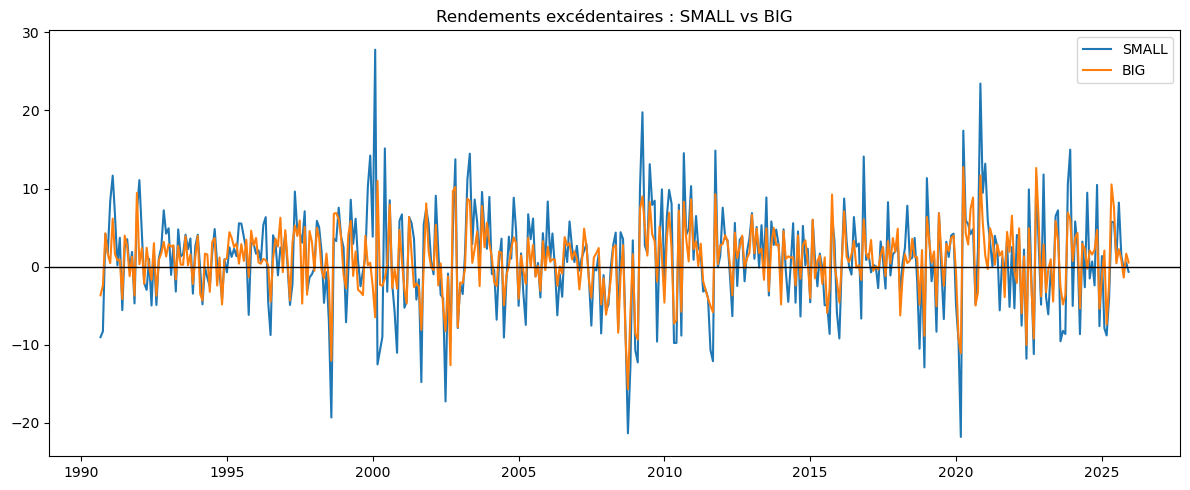

In [5]:
# ============================================================
# 2) VISUALISATION : RENDEMENTS EXCEDENTAIRES
# ============================================================

def plot_excess_returns(df: pd.DataFrame, save_name="rendements_excedentaires.png"):
    plt.figure(figsize=(12,5))
    plt.plot(df.index, df["SMALL_LoINV_RF"], label="SMALL")
    plt.plot(df.index, df["BIG_LoINV_RF"], label="BIG")
    plt.axhline(0, color="black", linewidth=1)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.title("Rendements excédentaires : SMALL vs BIG")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_excess_returns(df)


In [6]:
# ============================================================
# 3) STATIONNARITE : TEST ADF
# ============================================================

def adf_test(series: pd.Series, name: str):
    s = series.dropna()
    stat, pval, lags, nobs, *_ = adfuller(s, autolag="AIC")

    print(f"\n--- Test ADF pour {name} ---")
    print(f"Statistique ADF : {stat:.4f}")
    print(f"p-value         : {pval:.6f}")
    print(f"lags utilisés   : {lags}")
    print(f"observations    : {nobs}")

    if pval < 0.05:
        print("Conclusion : Série stationnaire (rejet H0)")
    else:
        print("Conclusion : Série non stationnaire (on ne rejette pas H0)")

adf_test(df["SMALL_LoINV_RF"], "SMALL_LoINV_RF")
adf_test(df["BIG_LoINV_RF"], "BIG_LoINV_RF")


--- Test ADF pour SMALL_LoINV_RF ---
Statistique ADF : -19.1345
p-value         : 0.000000
lags utilisés   : 0
observations    : 423
Conclusion : Série stationnaire (rejet H0)

--- Test ADF pour BIG_LoINV_RF ---
Statistique ADF : -15.8854
p-value         : 0.000000
lags utilisés   : 1
observations    : 422
Conclusion : Série stationnaire (rejet H0)


<Figure size 1200x400 with 0 Axes>

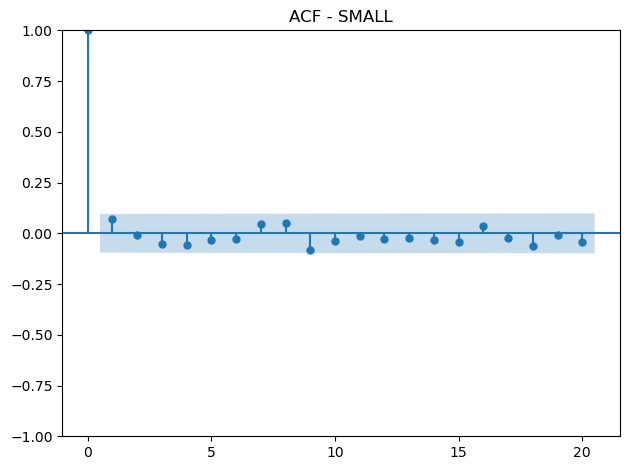

<Figure size 1200x400 with 0 Axes>

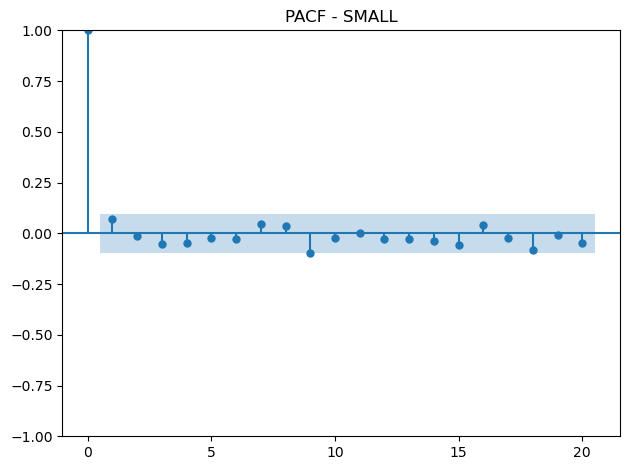

<Figure size 1200x400 with 0 Axes>

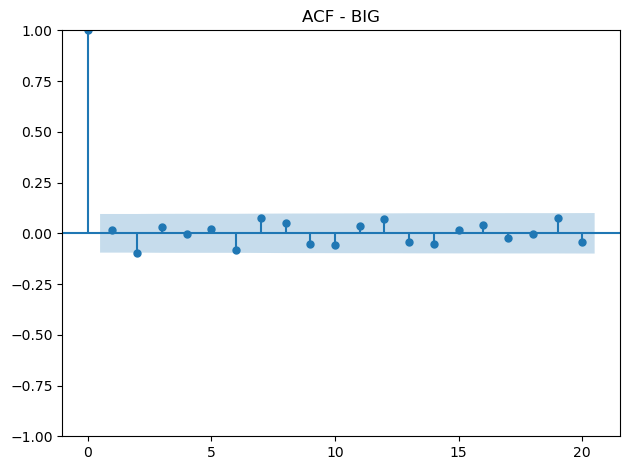

<Figure size 1200x400 with 0 Axes>

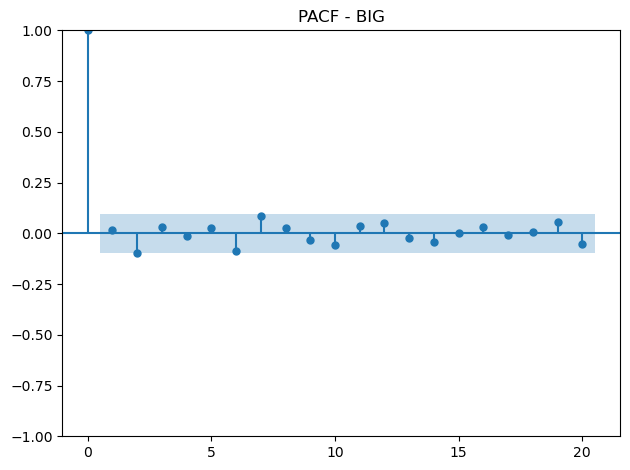

In [7]:
# ============================================================
# 4) ACF / PACF : IDENTIFICATION (ARIMA/ARMA)
# ============================================================

def plot_acf_pacf(series: pd.Series, name: str, lags=20):
    s = series.dropna()

    plt.figure(figsize=(12,4))
    plot_acf(s, lags=lags)
    plt.title(f"ACF - {name}")
    plt.tight_layout()
    
    plt.show()

    plt.figure(figsize=(12,4))
    plot_pacf(s, lags=lags, method="ywm")
    plt.title(f"PACF - {name}")
    plt.tight_layout()
    
    plt.show()

plot_acf_pacf(df["SMALL_LoINV_RF"], "SMALL")
plot_acf_pacf(df["BIG_LoINV_RF"], "BIG")

In [10]:
# =========================================================
# GRID SEARCH ARIMA (p,d,q) 
# =========================================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def grid_search_arima(series, p_max=6, q_max=6, d=0):
    series = series.dropna()
    results = []

    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                fit = model.fit()
                results.append({
                    "order": (p, d, q),
                    "AIC": fit.aic,
                    "BIC": fit.bic
                })
            except Exception:
                # on ignore les modèles qui plantent
                continue

    res = pd.DataFrame(results)

    # sécurité si aucun modèle n'a pu être estimé
    if res.empty:
        print("⚠️ Aucun modèle ARIMA n'a pu être estimé.")
        return res, None, None

    res = res.sort_values(["AIC", "BIC"]).reset_index(drop=True)
    best_aic = res.iloc[0]
    best_bic = res.sort_values("BIC").iloc[0]

    return res, best_aic, best_bic


# =========================
# SMALL
# =========================
res_small, best_aic_small, best_bic_small = grid_search_arima(df["SMALL_LoINV_RF"], p_max=6, q_max=6, d=0)

if best_aic_small is not None:
    print("SMALL - meilleur AIC :", best_aic_small["order"],
          "AIC=", round(best_aic_small["AIC"], 3),
          "BIC=", round(best_aic_small["BIC"], 3))
    print("SMALL - meilleur BIC :", best_bic_small["order"],
          "AIC=", round(best_bic_small["AIC"], 3),
          "BIC=", round(best_bic_small["BIC"], 3))


# =========================
# BIG
# =========================
res_big, best_aic_big, best_bic_big = grid_search_arima(df["BIG_LoINV_RF"], p_max=6, q_max=6, d=0)

if best_aic_big is not None:
    print("BIG - meilleur AIC :", best_aic_big["order"],
          "AIC=", round(best_aic_big["AIC"], 3),
          "BIC=", round(best_aic_big["BIC"], 3))
    print("BIG - meilleur BIC :", best_bic_big["order"],
          "AIC=", round(best_bic_big["AIC"], 3),
          "BIC=", round(best_bic_big["BIC"], 3))

SMALL - meilleur AIC : (2, 0, 1) AIC= 2761.304 BIC= 2781.553
SMALL - meilleur BIC : (0, 0, 0) AIC= 2769.643 BIC= 2777.742
BIG - meilleur AIC : (3, 0, 4) AIC= 2408.907 BIC= 2445.354
BIG - meilleur BIC : (0, 0, 0) AIC= 2414.638 BIC= 2422.738


In [11]:
# ============================================================
# 6) MODELE FAMA-FRENCH (5 facteurs) : OLS ROBUSTE HC3
# ============================================================

FACTORS = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

# (optionnel mais clean) : vérifier stationnarité des facteurs
for var in FACTORS:
    adf_test(df[var], var)

def fit_fama_french(df: pd.DataFrame, y_col: str, factors=FACTORS):
    X = sm.add_constant(df[factors])
    y = df[y_col]
    model = sm.OLS(y, X, missing="drop").fit(cov_type="HC3")
    return model

m_small = fit_fama_french(df, "SMALL_LoINV_RF")
m_big   = fit_fama_french(df, "BIG_LoINV_RF")

print(m_small.summary())
print(m_big.summary())


--- Test ADF pour Mkt_RF ---
Statistique ADF : -20.3576
p-value         : 0.000000
lags utilisés   : 0
observations    : 423
Conclusion : Série stationnaire (rejet H0)

--- Test ADF pour SMB ---
Statistique ADF : -21.3678
p-value         : 0.000000
lags utilisés   : 0
observations    : 423
Conclusion : Série stationnaire (rejet H0)

--- Test ADF pour HML ---
Statistique ADF : -17.6481
p-value         : 0.000000
lags utilisés   : 0
observations    : 423
Conclusion : Série stationnaire (rejet H0)

--- Test ADF pour RMW ---
Statistique ADF : -5.9164
p-value         : 0.000000
lags utilisés   : 12
observations    : 411
Conclusion : Série stationnaire (rejet H0)

--- Test ADF pour CMA ---
Statistique ADF : -4.8969
p-value         : 0.000035
lags utilisés   : 11
observations    : 412
Conclusion : Série stationnaire (rejet H0)
                            OLS Regression Results                            
Dep. Variable:         SMALL_LoINV_RF   R-squared:                       0.987
Model:   

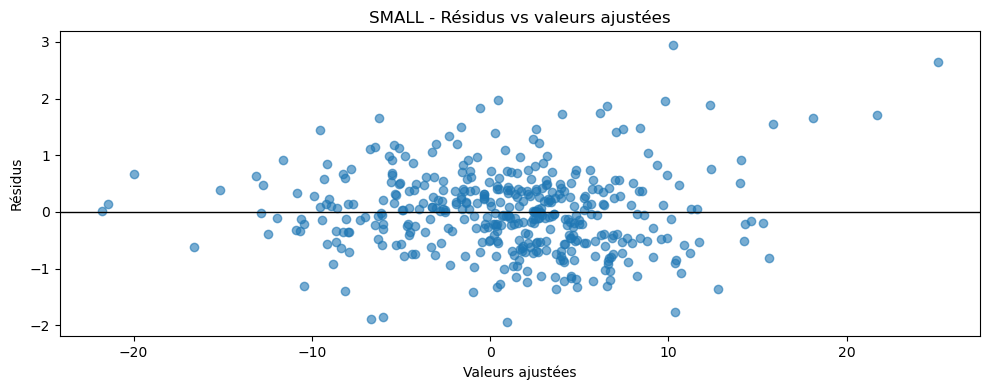

<Figure size 600x600 with 0 Axes>

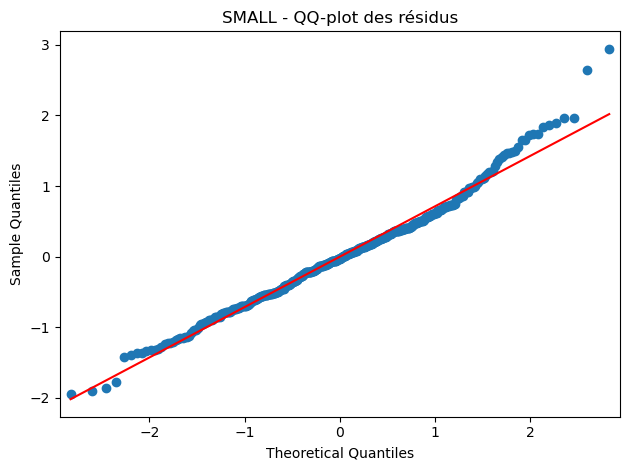

<Figure size 1000x400 with 0 Axes>

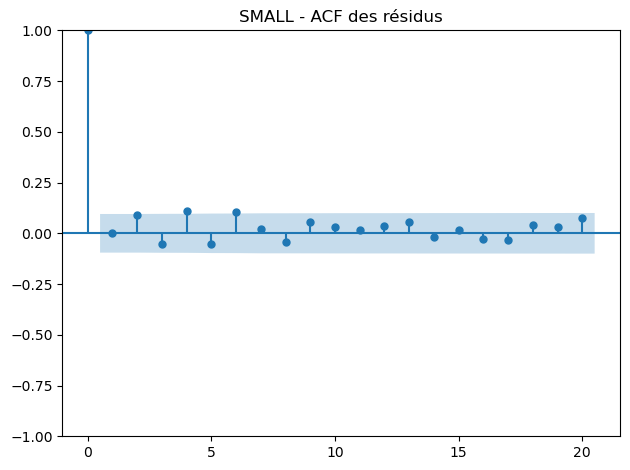

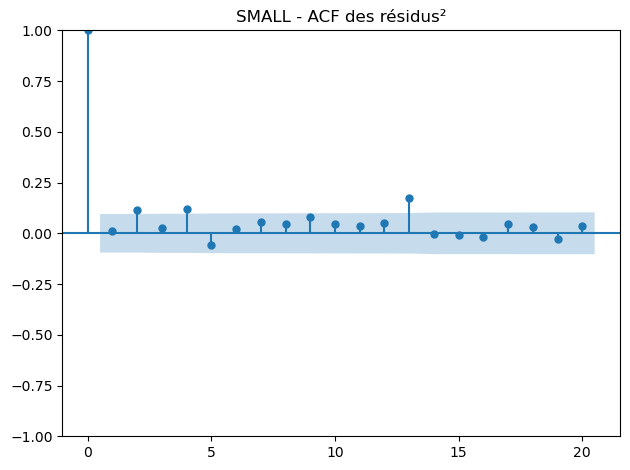


--- SMALL Ljung-Box (résidus) lag=12 ---
      lb_stat  lb_pvalue
12  19.434487   0.078569

--- SMALL Ljung-Box (résidus²) lag=12 ---
      lb_stat  lb_pvalue
12  21.831844   0.039448

--- SMALL ARCH test (nlags=12) ---
LM stat = 19.2503 | p-value = 0.082663
F stat  = 1.6297 | p-value = 0.080867


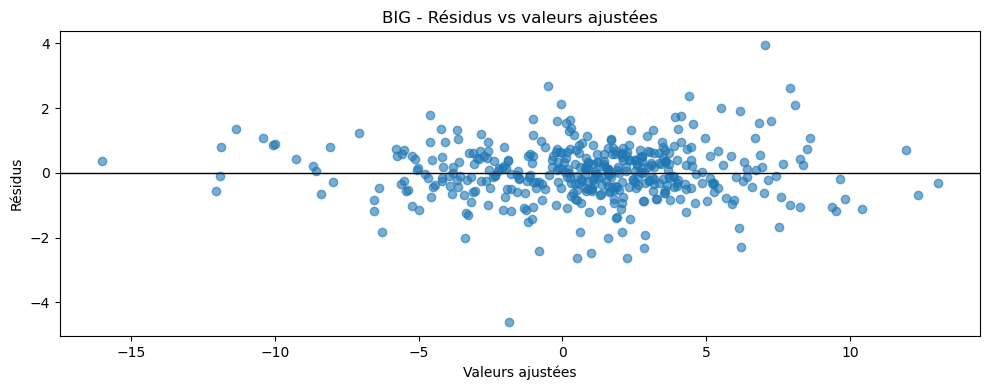

<Figure size 600x600 with 0 Axes>

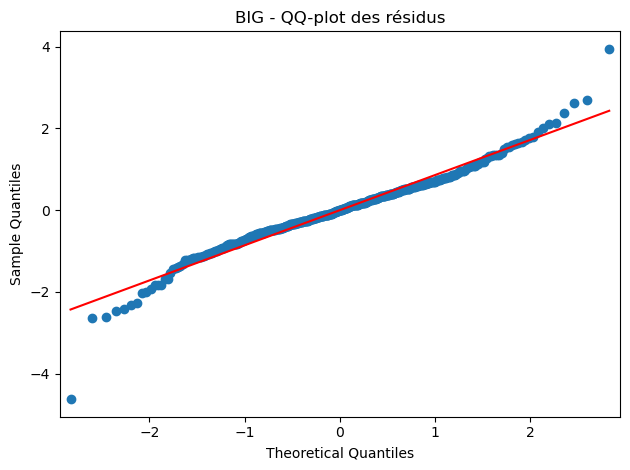

<Figure size 1000x400 with 0 Axes>

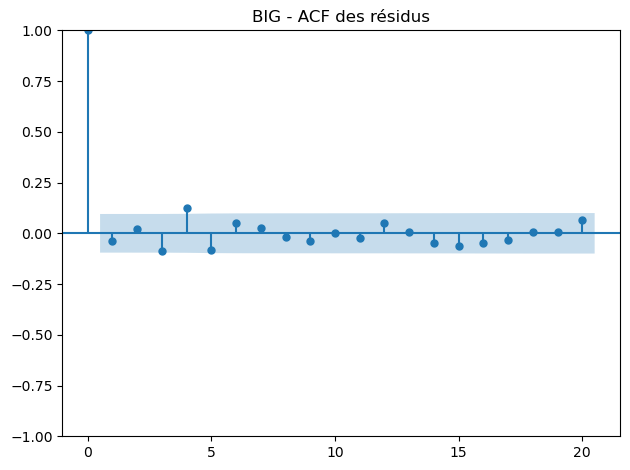

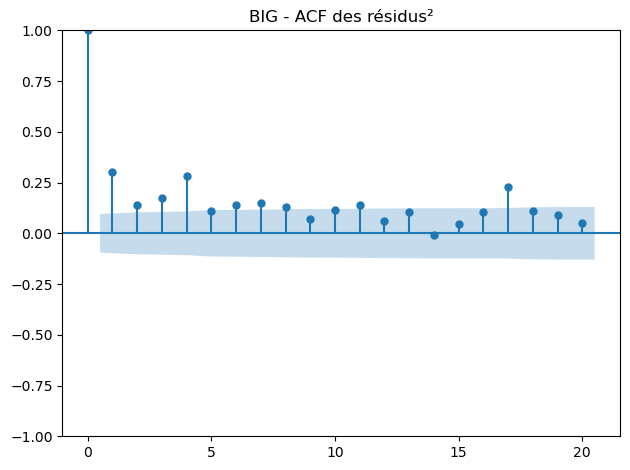


--- BIG Ljung-Box (résidus) lag=12 ---
      lb_stat  lb_pvalue
12  17.281122   0.139325

--- BIG Ljung-Box (résidus²) lag=12 ---
       lb_stat     lb_pvalue
12  143.156235  1.379472e-24

--- BIG ARCH test (nlags=12) ---
LM stat = 69.9343 | p-value = 0.000000
F stat  = 6.7979 | p-value = 0.000000


In [15]:
# ============================================================
# 8) DIAGNOSTIC RESIDUS (OLS) : PLOTS + ACF + TESTS
# ============================================================

def residual_plots(model, prefix="model"):
    resid = model.resid
    fitted = model.fittedvalues

    # Résidus vs fitted
    plt.figure(figsize=(10,4))
    plt.scatter(fitted, resid, alpha=0.6)
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{prefix} - Résidus vs valeurs ajustées")
    plt.xlabel("Valeurs ajustées")
    plt.ylabel("Résidus")
    plt.tight_layout()
    
    plt.show()
    plt.close()

    # QQ plot
    plt.figure(figsize=(6,6))
    sm.qqplot(resid, line="s")
    plt.title(f"{prefix} - QQ-plot des résidus")
    plt.tight_layout()

    plt.show()
    plt.close()

def acf_plots(resid: pd.Series, prefix="model", lags=20):
    plt.figure(figsize=(10,4))
    plot_acf(resid, lags=lags)
    plt.title(f"{prefix} - ACF des résidus")
    plt.tight_layout()
   
    plot_acf(resid**2, lags=lags)
    plt.title(f"{prefix} - ACF des résidus²")
    plt.tight_layout()
 
    plt.show()
    plt.close()

def ljung_tests(resid: pd.Series, name="", lag=12):
    lb_resid = acorr_ljungbox(resid, lags=[lag], return_df=True)
    lb_sq    = acorr_ljungbox(resid**2, lags=[lag], return_df=True)

    print(f"\n--- {name} Ljung-Box (résidus) lag={lag} ---")
    print(lb_resid)

    print(f"\n--- {name} Ljung-Box (résidus²) lag={lag} ---")
    print(lb_sq)

def arch_test(resid: pd.Series, name="", nlags=12):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=nlags)
    print(f"\n--- {name} ARCH test (nlags={nlags}) ---")
    print(f"LM stat = {lm_stat:.4f} | p-value = {lm_pvalue:.6f}")
    print(f"F stat  = {f_stat:.4f} | p-value = {f_pvalue:.6f}")

# SMALL
residual_plots(m_small, "SMALL")
acf_plots(m_small.resid, "SMALL")
ljung_tests(m_small.resid, "SMALL")
arch_test(m_small.resid, "SMALL")

# BIG
residual_plots(m_big, "BIG")
acf_plots(m_big.resid, "BIG")
ljung_tests(m_big.resid, "BIG")
arch_test(m_big.resid, "BIG")

In [34]:
# ============================================================
# 9) COMPARAISON MODELES GARCH : AIC/BIC
# ============================================================

candidates = [(1,1), (1,2), (2,1)]
rows = []

for p, q in candidates:
    res = fit_garch(y_big, p=p, q=q, dist="t")
    rows.append({"Model": f"GARCH({p},{q})", "AIC": res.aic, "BIC": res.bic})

pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)

,Model,AIC,BIC
0,"GARCH(1,1)",6275.465405,6295.714072
1,"GARCH(1,2)",6277.204889,6301.503290
2,"GARCH(2,1)",6277.465405,6301.763806


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                 BIG_LoINV_RF   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3132.73
Distribution:      Standardized Student's t   AIC:                           6275.47
Method:                  Maximum Likelihood   BIC:                           6295.71
                                              No. Observations:                  424
Date:                      Mon, Mar 02 2026   Df Residuals:                      423
Time:                              23:11:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

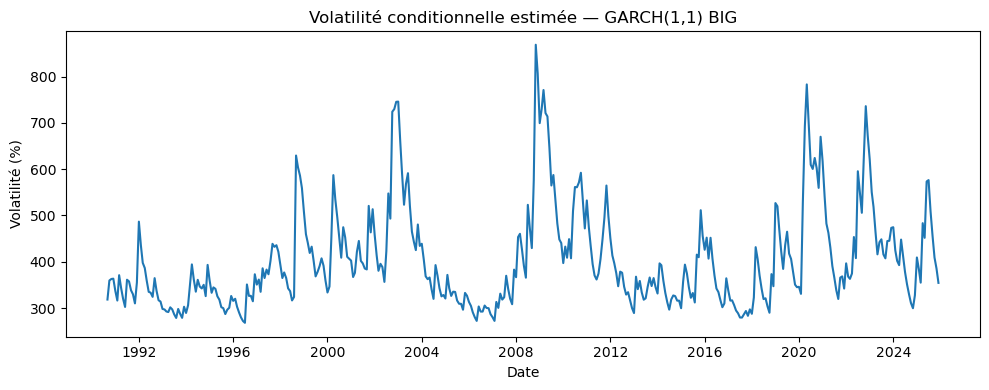

In [33]:
# ============================================================
# 10) GARCH(1,1) SUR BIG — ESTIMATION PROPRE
# ============================================================

from arch import arch_model
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1) Série en % (stabilité numérique)
# ------------------------------------------------------------
y_big = df["BIG_LoINV_RF"].dropna() * 100

# ------------------------------------------------------------
# 2) Estimation GARCH(1,1) avec Student-t
# ------------------------------------------------------------
garch_model = arch_model(
    y_big,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_res = garch_model.fit(disp="off")

# ------------------------------------------------------------
# 3) Affichage UNIQUE dans le notebook
# ------------------------------------------------------------
print(garch_res.summary())

# ------------------------------------------------------------
# 6) Volatilité conditionnelle estimée
# ------------------------------------------------------------
cond_vol = pd.Series(
    garch_res.conditional_volatility,
    index=y_big.index
)

plt.figure(figsize=(10, 4))
plt.plot(cond_vol)
plt.title("Volatilité conditionnelle estimée — GARCH(1,1) BIG")
plt.xlabel("Date")
plt.ylabel("Volatilité (%)")
plt.tight_layout()
plt.show()

,Model,AIC,BIC
0,"GARCH(1,1)",6275.465405,6295.714072
1,"GARCH(1,2)",6277.204889,6301.503290
2,"GARCH(2,1)",6277.465405,6301.763806


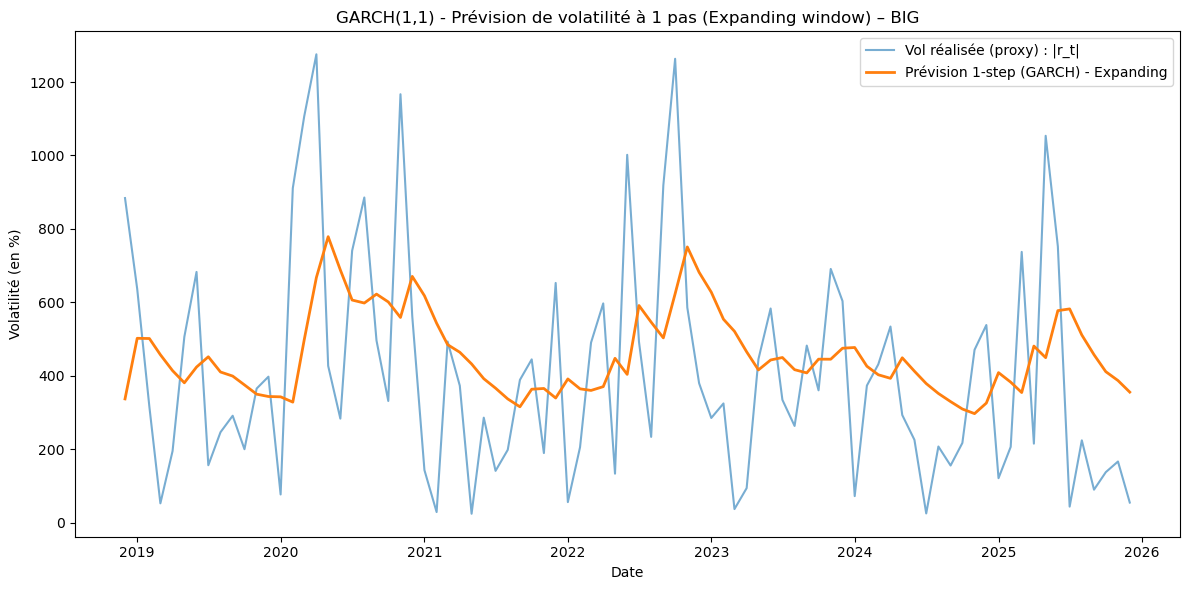

In [22]:
# ============================================================
# 11) PREVISION OUT-OF-SAMPLE : 1-STEP AHEAD (EXPANDING WINDOW)
# ============================================================

def expanding_window_forecast(y: pd.Series, split_ratio=0.8):
    split = int(len(y) * split_ratio)
    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    sigma_real = y_test.abs()  # proxy simple
    sigma_pred = pd.Series(index=y_test.index, dtype=float)

    for t in y_test.index:
        end_loc = y.index.get_loc(t)
        y_known = y.iloc[:end_loc]

        try:
            res = fit_garch(y_known, p=1, q=1, dist="t")
            f = res.forecast(horizon=1, reindex=False)
            var_next = f.variance.values[-1, 0]
            sigma_pred.loc[t] = np.sqrt(var_next)
        except:
            sigma_pred.loc[t] = np.nan

    out = pd.DataFrame({
        "y_test_percent": y_test,
        "sigma_real_abs_rt": sigma_real,
        "sigma_pred_garch_expanding": sigma_pred
    })
    return out


# Plot validation
plt.figure(figsize=(12,6))
plt.plot(out_forecast.index, out_forecast["sigma_real_abs_rt"], label="Vol réalisée (proxy) : |r_t|", alpha=0.6)
plt.plot(out_forecast.index, out_forecast["sigma_pred_garch_expanding"], label="Prévision 1-step (GARCH) - Expanding", linewidth=2)
plt.title("GARCH(1,1) - Prévision de volatilité à 1 pas (Expanding window) – BIG")
plt.xlabel("Date")
plt.ylabel("Volatilité (en %)")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


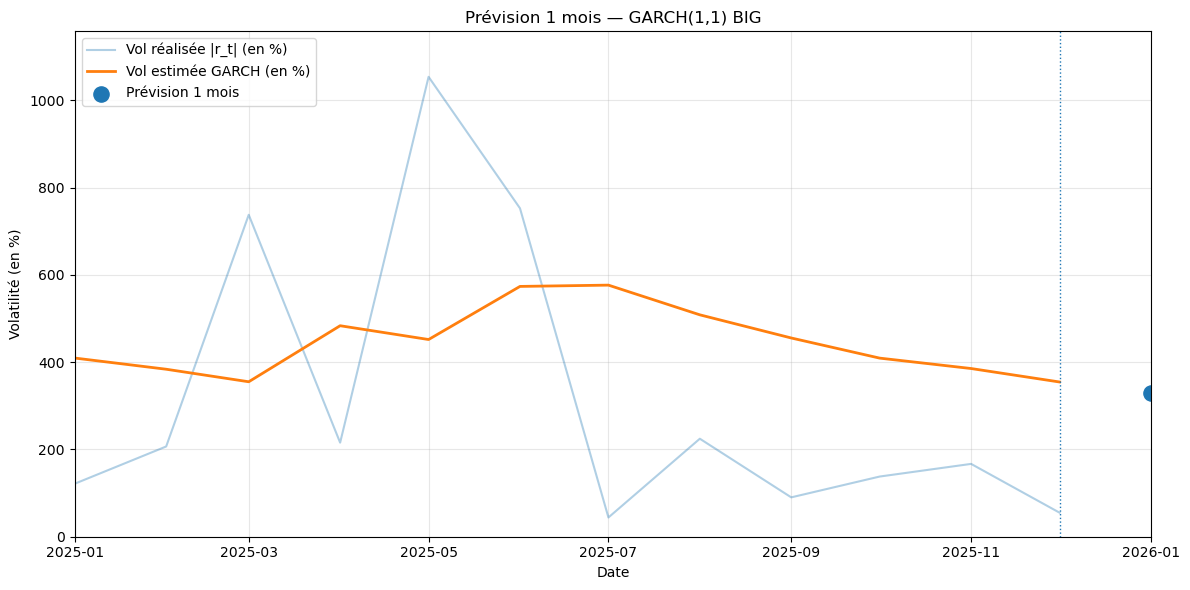

Date prévue : 2026-01-01 00:00:00
Volatilité prévue (%) : 329.526


In [35]:
# ============================================================
# 12) PREVISION 1 MOIS AHEAD — GRAPHIQUE UNIQUEMENT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Série propre
y = y_big.copy()
y.index = pd.to_datetime(y.index)
y = y.sort_index()

# Estimation GARCH sur toute la base
res_full = fit_garch(y, p=1, q=1, dist="t")

# Prévision 1 mois
f = res_full.forecast(horizon=1, reindex=False)
var_next = f.variance.values[-1, 0]
sigma_next = float(np.sqrt(var_next))

last_date = y.index[-1]
future_date = last_date + pd.offsets.MonthBegin(1)

# Volatilité réalisée (proxy) et estimée
sigma_real = y.abs()
sigma_fitted = pd.Series(res_full.conditional_volatility, index=y.index)

# Zoom 2025 → date future
start_zoom = pd.Timestamp("2025-01-01")
real_zoom = sigma_real.loc[start_zoom:last_date]
fit_zoom  = sigma_fitted.loc[start_zoom:last_date]

# ----------- GRAPHIQUE -----------
plt.figure(figsize=(12,6))

plt.plot(real_zoom.index, real_zoom.values,
         label="Vol réalisée |r_t| (en %)", alpha=0.35)

plt.plot(fit_zoom.index, fit_zoom.values,
         label="Vol estimée GARCH (en %)", linewidth=2)

plt.scatter([future_date], [sigma_next],
            s=120, label="Prévision 1 mois")

plt.axvline(last_date, linestyle=":", linewidth=1)

plt.xlim(start_zoom, future_date)
plt.ylim(0, max(real_zoom.max(), fit_zoom.max(), sigma_next) * 1.10)

plt.title("Prévision 1 mois — GARCH(1,1) BIG")
plt.xlabel("Date")
plt.ylabel("Volatilité (en %)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()

print("Date prévue :", future_date)
print("Volatilité prévue (%) :", round(sigma_next, 3))